In [1]:
import os 
from pathlib import Path
root = os.getcwd()
folders = {
    "systematic_review": f"{root}/systematic_review",
        "protocol": f"{root}/systematic_review/protocol",
            "prospero": f"{root}/systematic_review/protocol/prospero",
            "cochrane": f"{root}/systematic_review/protocol/cochrane",
        "search_strategy": f"{root}/systematic_review/search_strategy",
        "search": f"{root}/systematic_review/search",
        "deduplication": f"{root}/systematic_review/deduplication",
        "screening": f"{root}/systematic_review/screening",
            "title_abstract": f"{root}/systematic_review/screening/title_abstract_screening", 
            "pdf": f"{root}/systematic_review/screening/PDF",
            "full_text": f"{root}/systematic_review/screening/full_text_screening", 
    "data_collection": f"{root}/data_collection",
        "database": f"{root}/data_collection/database",
    "meta-analysis": f"{root}/meta-analysis",
    "manuscript": f"{root}/manuscript"
}

for x, y in folders.items():
    filename = f"{x}"
    path = Path(f"{y}")
    os.makedirs(path, exist_ok = True)
    globals()[filename] = path

<a id="search_strategy"></a>

<h2 align="center" style="font-family:Times New Roman;font-variant: small-caps;">Search Strategy</h2>

Search strategy builder using terms and field tags, connected by Boolean operators. The results are saved into a plain text file, which is used to query literature search results from PubMed/MEDLINE. The search strategy is also translated into Embase and Web of Science Advanced Search syntax. (Coming soon: search results from the latter two databases in addition to PubMed/MEDLINE).

In [2]:
!pip install biopython

   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   --------------- ------------------------ 1.0/2.7 MB 11.1 MB/s eta 0:00:01
   ---------------------------------------- 2.7/2.7 MB 12.1 MB/s  0:00:00
   ---------------------------------------- 0.0/12.5 MB ? eta -:--:--
   ---------------------------------------  12.3/12.5 MB 66.4 MB/s eta 0:00:01
   ---------------------------------------- 12.5/12.5 MB 55.7 MB/s  0:00:00

   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [numpy]
   ---------------------------------------- 0/2 [n

In [1]:
import ipywidgets as widgets
from IPython.display import display, HTML

entries = []

term_input = widgets.Text(
    placeholder="Search term",
    layout = widgets.Layout(width="75%")
)

field_tag = widgets.Dropdown(
    options=[
        ("MeSH term", "mh"),
        ("Title", "ti"),
        ("Title / Abstract", "tiab"),
        ("Publication Type", "pt"),
    ],
    value="mh",
    layout=widgets.Layout(width="15%")
)

boolean = widgets.Dropdown(
    options=["OR", "AND", "NOT", ""],
    value="",
    layout=widgets.Layout(width="10%")
)

filename_input = widgets.Text(
    placeholder="File name",
    layout=widgets.Layout(width="99.5%")
)

add_button = widgets.Button(description="Add", icon="plus", button_style="success")
delete_button = widgets.Button(description="Delete", icon="minus", button_style="danger")
clear_button = widgets.Button(description="Clear",icon="left-arrow", button_style="warning")
save_button = widgets.Button(description="Save", icon="save", button_style="info")
output = widgets.Output()

def build_query(entries):
    parts = []
    current_or_group = []

    for entry in entries:
        term = entry["term"].strip()
        field = entry["field"]
        op = entry["boolean"]

        if not term:
            continue

        current_or_group.append(f'"{term}"[{field}]')

        if op == "OR":
            continue

        parts.append("(" + " OR ".join(current_or_group) + ")")
        current_or_group = []

        if op in ("AND", "NOT"):
            parts.append(op)

    if current_or_group:
        parts.append("(" + " OR ".join(current_or_group) + ")")

    return " ".join(parts)

def refresh_output(message=""):
    with output:
        clear_output()
        if message:
            print(message)
            print()

        print("Entries:")
        if entries:
            for i, entry in enumerate(entries, start=1):
                op_label = entry["boolean"] if entry["boolean"] != "" else "END"
                print(f'{i}. "{entry["term"]}" [{entry["field"]}] -> {op_label}')
        else:
            print("[none]")

        print("\nCurrent query:")
        query = build_query(entries)
        print(query if query else "[empty]")

def add_entry(_):
    term = term_input.value.strip()
    field = field_tag.value
    op = boolean.value

    if not term:
        refresh_output("Please enter a term.")
        return

    entries.append({
        "term": term,
        "field": field,
        "boolean": op
    })

    term_input.value = ""
    refresh_output(f'Added: "{term}"[{field}] -> {op if op else "END"}')

def delete_last_entry(_):
    if not entries:
        refresh_output("Nothing to delete.")
        return
    removed = entries.pop()
    refresh_output(
        f'Removed: "{removed["term"]}"[{removed["field"]}] -> {removed["boolean"] if removed["boolean"] else "END"}'
    )

def clear_all_entries(_):
    entries.clear()
    refresh_output("Cleared all entries.")

def save_query(_):
    query = build_query(entries)
    filename = filename_input.value.strip() or "default_strategy"
    filepath = f"./search_strategy/{filename}.txt"
    
    with open(filepath, "w", encoding="utf-8") as f:
        f.write(query)

    refresh_output(f"Saved query to {filepath}")
    return filepath

add_button.on_click(add_entry)
delete_button.on_click(delete_last_entry)
clear_button.on_click(clear_all_entries)
save_button.on_click(save_query)

entry_row = widgets.HBox(children = [term_input, field_tag, boolean], layout = {"width":"100%"})
buttons = widgets.HBox(children = [add_button, delete_button, clear_button, save_button], layout = {"width":"600px", "justify_content":"center", "align_items":"center"})
controls = widgets.VBox(children = [filename_input, entry_row, buttons, output], layout = {"width":"800px", 
                                                                                           #"height":"100vh", 
                                                                                           #"justify_content":"center", 
                                                                                           #"align_items":"center"
                                                                                          })


term_input.add_class("textinput")
field_tag.add_class("dropdown")
boolean.add_class("dropdown")
filename_input.add_class("textinput")
entry_row.add_class("hbox")
add_button.add_class("button")
delete_button.add_class("button")
clear_button.add_class("button")
save_button.add_class("button")


# css styling


display(HTML("""
<style>
.unicode {
    font-size: 16px;
}

.textinput input {
    border-radius: 20px !important;
    font-size: 20px;
}

.dropdown select {
    border-radius: 20px !important;
    font-size: 12px;
}

.hbox {
    border-radius: 20px !important;
    font-size: 12px;
    width: 70%;
}

.button {
    border-radius: 20px !important;
    font-size: 12px;
    width: 15%;
}

</style>"""))

display(controls)


**Search strategy** used for network meta-analysis project in 2026.

|       |              |                                                                                           |
| :---: | :----------- | :---------------------------------------------------------------------------------------- |
| **P** | Population   | ```NOT (("pediatric"[tiab] OR "paediatric"[tiab]) OR ("revision"[tiab] OR "repair"[tiab]))``` |
| **I** | Intervention | ```("anterior cruciate ligament"[mh] OR "anterior cruciate ligament"[tiab] OR "anterior cruciate ligament reconstruction"[tiab] OR "acl"[tiab])``` |
| **C** | Comparators  | ```("bone-patellar tendon-bone"[tiab] OR "patellar tendon"[tiab] OR "bptb"[tiab])``` <br> ```("hamstring tendon"[tiab] OR "semitendinosus"[tiab] OR "gracilis"[tiab])``` <br> `("quadriceps"[tiab] OR "quadriceps tendon"[tiab] OR "qt"[tiab])` <br> `("peroneus longus"[tiab] OR "fibularis longus"[tiab])` <br> `("achilles"[tiab])` <br> `("tibialis anterior"[tiab] OR "tibialis posterior"[tiab]` |
| **O** | Outcomes     | `("ikdc"[tiab] OR "lysholm"[tiab] OR "tegner"[tiab] OR (("instrumental laxity"[tiab] OR "kt-1000"[tiab] OR "kt-2000"[tiab] OR "rolimeter"[tiab]) OR "pivot shift"[tiab] OR "lachman"[tiab]) OR ("graft failure"[tiab] OR "graft rupture"[tiab]))`                   |
| **S** | Study design | `("randomized controlled trial"[pt] OR "randomized controlled trial"[tiab] OR "randomised controlled trial"[tiab]) NOT ("review"[pt] OR "review"[tiab] OR "systematic review"[pt] OR "systematic review"[tiab] OR "meta-analysis"[pt] OR "meta-analysis"[tiab])`   |

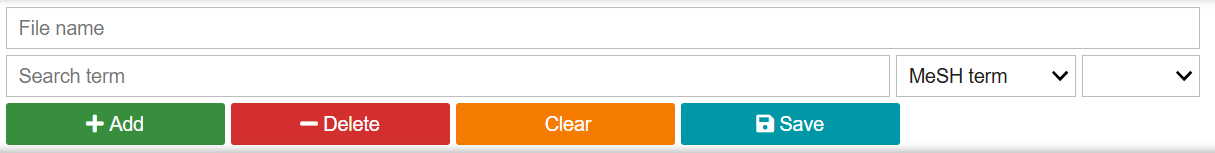

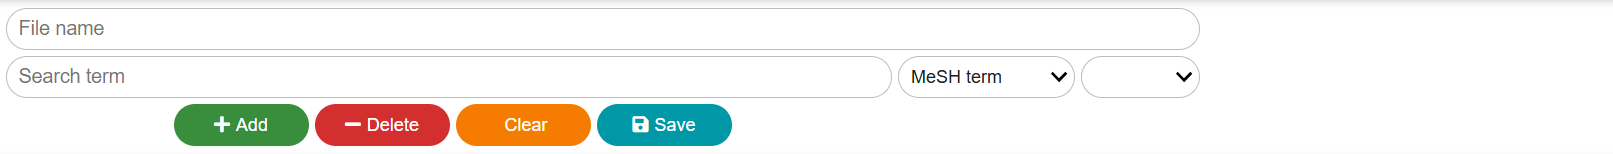